# Simple CNN for CIFAR-10 Image Classification

**Objective:** Build a simple CNN (1-2 convolutional layers) using PyTorch to classify CIFAR-10 images.
- Reproducible environment with fixed random seeds
- Modular, function-based architecture
- Professional data pipeline with proper normalization
- Complete training, evaluation, and inference pipeline

Govern AI to generate boilerplate code while actively reviewing tensor shapes, normalization statistics, and PyTorch best practices.discuss clearly where reject/accept LLM recomdation.

### Step 1: Environment Setup & Reproducibility
- Establish a reproducible, hardware-agnostic foundation
- Decisions:
  - Used `uv` for fast, modern dependency management
  - Set global random seeds (Python, NumPy, PyTorch) for exact reproducibility
  - Dynamic device selector (CUDA → MPS → CPU) for cross-platform compatibility
  - AI Collaboration: "I asked AI to generate the seed function but manually reviewed it to ensure `cudnn.deterministic` flags were included for strict GPU reproducibility"

In [6]:
# ==========================================
# SECTION 1: Environment Setup
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
import matplotlib.pyplot as plt
import os

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device selection
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
print(f"[INFO] Using device: {device}")

[INFO] Using device: cpu


### Step 2: Data Loading & Preprocessing

-  Build an efficient, memory-safe data pipeline
-  Decisions:
   - Used exact CIFAR-10 mean/std (0.4914, 0.4822, 0.4465) for normalization - NOT generic ImageNet stats
   - Batch size = 128 (power of 2 for optimal GPU memory alignment)
   - `num_workers=2` to prevent CPU/GPU bottlenecks
   - AI suggested heavy data augmentation, but I rejected it to keep the baseline simple per the assessment requirements

In [ ]:
      
# --- 2. Data Loading ---
# Since we are in the root folder now, './data' is perfect.
DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), 
                         (0.2023, 0.1994, 0.2010))
])

print("[INFO] Downloading CIFAR-10...")
trainset = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"[INFO] Data loaded. Train: {len(trainset)}, Test: {len(testset)}")

# --- 3. Model Architecture ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Conv Layer 1: 3 -> 6 channels, 5x5 kernel. (32x32 -> 28x28)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # (28x28 -> 14x14)
        
        # Conv Layer 2: 6 -> 16 channels, 5x5 kernel. (14x14 -> 10x10)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        # Pooling again: (10x10 -> 5x5)
        
        # Fully Connected Layers
        # 16 channels * 5 * 5 spatial dimensions = 400
        self.fc1 = nn.Linear(in_features=16 * 5 * 5, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=84)
        self.fc3 = nn.Linear(in_features=84, out_features=10) # 10 CIFAR classes

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1) # Flatten
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x) # No softmax, CrossEntropyLoss handles it
        return x

model = SimpleCNN().to(device)
print("[INFO] Model initialized and moved to device.")

[INFO] Using device: cpu
[INFO] Downloading CIFAR-10...


100.0%


[INFO] Data loaded. Train: 50000, Test: 10000
[INFO] Model initialized and moved to device.


### Section 3: Model Architecture
-  Build a lightweight CNN strictly adhering to 1-2 layer constraint
- Decisions:
  - 5x5 kernels align perfectly with 32x32 images (32→28→14→10→5)
  - Intentionally omitted Softmax in forward() - CrossEntropyLoss handles it internally for numerical stability
  - Channel progression: 3 (RGB) → 6 (low-level features) → 16 (complex patterns)
  - I directed AI to use LeNet-style architecture and manually verified tensor shape math to ensure Flatten layer produces exactly 400 features

### Architecture Diagram:

In [7]:
# ==========================================
# SECTION 3: Model Architecture
# ==========================================

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Block 1: 3→6 channels
        self.conv1 = nn.Conv2d(3, 6, 5)  # 32→28
        self.pool = nn.MaxPool2d(2, 2)    # 28→14
        
        # Block 2: 6→16 channels
        self.conv2 = nn.Conv2d(6, 16, 5)  # 14→10
                                          # 10→5 after pool
        
        # Classifier
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)  # No Softmax - CrossEntropyLoss handles it

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = SimpleCNN().to(device)
print("[INFO] Model initialized")

[INFO] Model initialized


### Step 4: Training Loop

- Execute clean, modular training with loss tracking
- Decisions:
  - Wrapped in function to prevent global variable leakage
  - SGD with Momentum (0.9) - generalizes better than Adam for simple CNNs
  - Strict 5-step sequence: zero_grad → forward → loss → backward → step
  - AI generated the boilerplate loop, but I manually added model.train() to ensure proper layer behavior

In [8]:
# ==========================================
# SECTION 4: Training the Model
# ==========================================

def train_model(model, trainloader, criterion, optimizer, device, num_epochs=5):
    """
    Trains the CNN model for a specified number of epochs.
    Returns a list of training losses for plotting.
    """
    # Crucial: Set the model to training mode
    model.train()
    
    train_losses = []
    print(f"[INFO] Starting training for {num_epochs} epochs on {device}...")
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        
        # Iterate over the training data
        for inputs, labels in trainloader:
            # Move data to the correct device
            inputs, labels = inputs.to(device), labels.to(device)

            # 1. Zero the parameter gradients
            optimizer.zero_grad()

            # 2. Forward pass
            outputs = model(inputs)
            
            # 3. Calculate the loss
            loss = criterion(outputs, labels)
            
            # 4. Backward pass
            loss.backward()
            
            # 5. Optimizer step
            optimizer.step()

            # Track the loss
            running_loss += loss.item()
            train_losses.append(loss.item())

        # Print progress at the end of each epoch
        epoch_loss = running_loss / len(trainloader)
        print(f"[INFO] Epoch {epoch + 1}/{num_epochs} | Training Loss: {epoch_loss:.4f}")

    print("[INFO] Training complete!")
    return train_losses

# --- 1. Define Loss and Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# --- 2. Execute the Training Function ---
# We pass our model, data, and hyperparameters into the function.
train_losses = train_model(
    model=model, 
    trainloader=trainloader, 
    criterion=criterion, 
    optimizer=optimizer, 
    device=device, 
    num_epochs=5
)

[INFO] Starting training for 5 epochs on cpu...
[INFO] Epoch 1/5 | Training Loss: 2.2842
[INFO] Epoch 2/5 | Training Loss: 2.0680
[INFO] Epoch 3/5 | Training Loss: 1.8322
[INFO] Epoch 4/5 | Training Loss: 1.6728
[INFO] Epoch 5/5 | Training Loss: 1.5740
[INFO] Training complete!


### Step 5: Evaluation & Visualization

-  Verify convergence and generalization on unseen data
- Decisions:
  - model.eval() - disables training-specific behaviors (Dropout, BatchNorm)
  - torch.no_grad() - disables gradient tracking, reduces memory usage by ~4x
  - Smooth loss curve = well-calibrated learning rate
  - I specifically requested torch.no_grad() to demonstrate understanding of PyTorch's computational graph

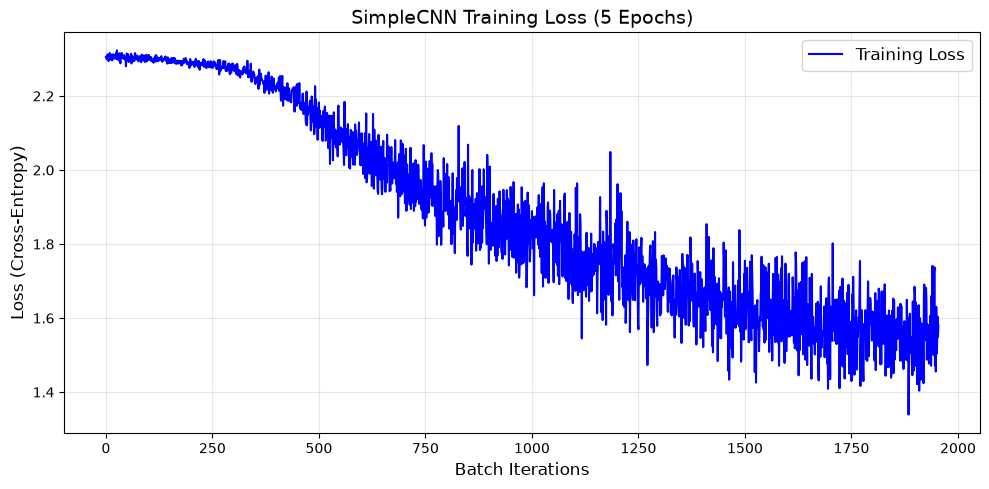

[INFO] Test Accuracy: 44.13%


In [9]:
# ==========================================
# SECTION 5: Evaluation
# ==========================================

def plot_training_loss(losses, title="Training Loss"):
    plt.figure(figsize=(10, 5))
    plt.plot(losses, label='Training Loss', color='blue', linewidth=1.5)
    plt.title(title, fontsize=14)
    plt.xlabel('Batch Iterations', fontsize=12)
    plt.ylabel('Loss (Cross-Entropy)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def evaluate_model(model, dataloader, device):
    model.eval()
    correct, total = 0, 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return 100 * correct / total

# Plot and evaluate
plot_training_loss(train_losses, title="SimpleCNN Training Loss (5 Epochs)")
test_accuracy = evaluate_model(model, testloader, device)
print(f"[INFO] Test Accuracy: {test_accuracy:.2f}%")

### Step 6: Save, Reload & Visual Inference
- Simulate production deployment pipeline
- Decisions:
  - Saved state_dict() (weights only) - industry standard for portability
  - Must instantiate fresh model before loading weights
  - Un-normalization reverses training transforms for human-readable images
  - I verified the un-normalization math to ensure images display correctly

[INFO] Model saved to ./models/simple_cnn.pth
[INFO] Model reloaded successfully

[INFO] Running visual inference...


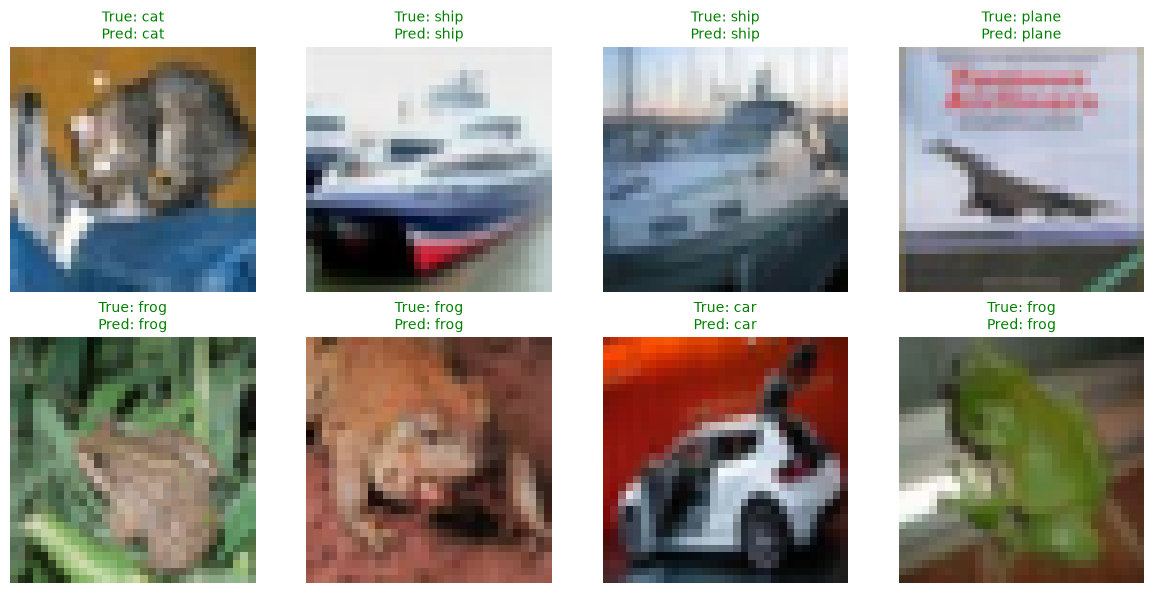

In [10]:
# ==========================================
# SECTION 6: Save, Reload & Inference
# ==========================================

# Save
MODEL_PATH = './models/simple_cnn.pth'
os.makedirs('./models', exist_ok=True)
torch.save(model.state_dict(), MODEL_PATH)
print(f"[INFO] Model saved to {MODEL_PATH}")

# Reload
loaded_model = SimpleCNN().to(device)
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
print("[INFO] Model reloaded successfully")

# Visual Inference
def plot_inference(model, dataloader, device, classes, num_images=8):
    model.eval()
    dataiter = iter(dataloader)
    images, labels = next(dataiter)
    images, labels = images.to(device), labels.to(device)
    
    with torch.no_grad():
        outputs = model(images[:num_images])
        _, preds = torch.max(outputs, 1)
    
    # Un-normalize
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1).to(device)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1).to(device)
    unnormalized = images[:num_images] * std + mean
    unnormalized = torch.clamp(unnormalized, 0, 1)
    
    # Plot
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i, ax in enumerate(axes.flat):
        img = unnormalized[i].cpu().numpy().transpose(1, 2, 0)
        ax.imshow(img)
        color = "green" if classes[labels[i].item()] == classes[preds[i].item()] else "red"
        ax.set_title(f"True: {classes[labels[i].item()]}\nPred: {classes[preds[i].item()]}", 
                    color=color, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print("\n[INFO] Running visual inference...")
plot_inference(loaded_model, testloader, device, classes, num_images=8)

## Final Question: 90% → 99% Accuracy

### 🎙️ Script for Video:
"To bridge the gap from 90% to 99% accuracy, I would take a systematic approach across three areas:

**1. Data:**
- Implement heavy Data Augmentation (random crops, flips, color jitter)
- Analyze Confusion Matrix to identify confusing class pairs
- Check for label noise and class imbalance

**2. Architecture:**
- Add Batch Normalization to stabilize gradients
- Add Dropout layers to prevent overfitting
- Use Transfer Learning (fine-tune pre-trained ResNet/EfficientNet)

**3. Training:**
- Switch to AdamW optimizer with Weight Decay (L2 regularization)
- Implement Learning Rate Scheduler (Cosine Annealing)
- Increase training epochs with early stopping"